In [ ]:
!pip install transformers datasets torch torchvision pillow pytesseract

In [ ]:
import os
import json
import torch
import numpy as np
from PIL import Image
from datasets import Dataset, DatasetDict
from difflib import SequenceMatcher
from transformers import (
    AutoProcessor,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DefaultDataCollator
)

In [ ]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_DIR = "./sroie-datasetv2/SROIE2019"
MODEL_ID = "microsoft/layoutlmv3-base"
OUTPUT_DIR = "./layoutlmv3-sroie-model"

# Flat labels based on your JSON structure
LABELS = ["O", "COMPANY", "DATE", "ADDRESS", "TOTAL"]
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

In [ ]:
# ==========================================
# 2. HYBRID RAM-FRIENDLY DATA PARSER
# ==========================================
def normalize_bbox(box, width, height):
    return [
        max(0, min(1000, int(1000 * (box[0] / width)))),
        max(0, min(1000, int(1000 * (box[1] / height)))),
        max(0, min(1000, int(1000 * (box[2] / width)))),
        max(0, min(1000, int(1000 * (box[3] / height)))),
    ]

def fuzzy_match(fragment, entity_string, is_address=False, threshold=0.8):
    """Fuzzy matches text to handle OCR typos and greedy overlaps."""
    if not entity_string or not fragment: return False

    # Direct substring match (fast path)
    if fragment in entity_string:
        return True

    fragment_words = fragment.split()
    entity_words = entity_string.split()

    match_count = 0
    for fw in fragment_words:
        if any(SequenceMatcher(None, fw, ew).ratio() > threshold for ew in entity_words):
            match_count += 1

    # If it's an address, require at least 50% of the words to match to prevent stray numbers triggering it
    if is_address:
        return len(fragment_words) > 0 and (match_count / len(fragment_words)) >= 0.5

    # For shorter fields (Company/Date/Total), require a higher percentage of the phrase to match
    return len(fragment_words) > 0 and match_count == len(fragment_words)

def load_sroie_split_hybrid(split_name):
    split_dir = os.path.join(DATASET_DIR, split_name)
    img_dir, box_dir, ent_dir = [os.path.join(split_dir, f) for f in ["img", "box", "entities"]]

    examples = {"image_path": [], "words": [], "bboxes": [], "ner_tags": []}

    for filename in os.listdir(img_dir):
        if not filename.endswith(".jpg"): continue
        file_id = filename.split(".")[0]

        img_path = os.path.join(img_dir, filename)
        box_path = os.path.join(box_dir, file_id + ".txt")
        ent_path = os.path.join(ent_dir, file_id + ".txt")

        if not (os.path.exists(box_path) and os.path.exists(ent_path)): continue

        try:
            with Image.open(img_path) as img:
                width, height = img.size
            with open(ent_path, 'r', encoding='utf-8', errors='ignore') as f:
                entities = json.load(f)
        except Exception:
            continue

        doc_words, doc_bboxes, doc_ner_tags = [], [], []

        # Step 1: Read all lines first so we can sort them spatially
        raw_lines = []
        with open(box_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 9: continue

                coords = [int(p) for p in parts[:8]]
                text_fragment = ",".join(parts[8:]).strip()

                x_min = min(coords[0], coords[2], coords[4], coords[6])
                y_min = min(coords[1], coords[3], coords[5], coords[7])
                x_max = max(coords[0], coords[2], coords[4], coords[6])
                y_max = max(coords[1], coords[3], coords[5], coords[7])

                if x_max <= x_min or y_max <= y_min: continue

                raw_lines.append({
                    "text": text_fragment,
                    "box": [x_min, y_min, x_max, y_max],
                    "y_min": y_min
                })

        # Step 2: Sort top-to-bottom based on the Y-axis
        raw_lines = sorted(raw_lines, key=lambda x: x["y_min"])

        # Step 3: State Machine Checkpoints
        found_date = False
        found_total = False

        for line_data in raw_lines:
            text_fragment = line_data["text"]
            box = line_data["box"]
            norm_box = normalize_bbox(box, width, height)

            assigned_label = "O"
            for key, full_string in entities.items():
                is_addr = (key.upper() == "ADDRESS")
                if fuzzy_match(text_fragment, full_string, is_address=is_addr):
                    assigned_label = key.upper()
                    break

            # --- TOP-TO-BOTTOM LOGIC ---
            if assigned_label == "TOTAL":
                found_total = True
            if assigned_label == "DATE":
                found_date = True

            # The Lockouts
            if assigned_label == "ADDRESS" and found_total:
                assigned_label = "O"
            if assigned_label == "COMPANY" and (found_date or found_total):
                assigned_label = "O"
            # ---------------------------

            # --- WORD SPLITTING LOGIC ---
            # Chop the fragment into individual words but map them to the same box
            for word in text_fragment.split():
                doc_words.append(word)
                doc_bboxes.append(norm_box)
                doc_ner_tags.append(LABEL2ID[assigned_label])
            # ----------------------------

        examples["image_path"].append(img_path)
        examples["words"].append(doc_words)
        examples["bboxes"].append(doc_bboxes)
        examples["ner_tags"].append(doc_ner_tags)

    return Dataset.from_dict(examples)

In [ ]:
# ==========================================
# 3. INITIALIZATION & PREPROCESSING (HYBRID)
# ==========================================
print("Loading and parsing raw data with Hybrid logic...")
raw_datasets = DatasetDict({
    "train": load_sroie_split_hybrid("train"),
    "test": load_sroie_split_hybrid("test")
})

processor = AutoProcessor.from_pretrained(MODEL_ID, apply_ocr=False)

# Re-initializing the base model with the new flat 5-label classification head
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    num_labels=len(LABELS),
    ignore_mismatched_sizes=True # Required to drop the base model's default 2-label head
)

def prepare_dataset(batch):
    # Open images on the fly during the mapping process
    images = [Image.open(path).convert("RGB") for path in batch["image_path"]]

    # Return lightweight lists instead of heavy tensors for OOM safety
    encoding = processor(
        images,
        batch["words"],
        boxes=batch["bboxes"],
        word_labels=batch["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    return encoding

print("Tokenizing data (Optimized for low RAM)...")
encoded_datasets = raw_datasets.map(
    prepare_dataset,
    batched=True,
    batch_size=2,
    writer_batch_size=2,
    remove_columns=raw_datasets["train"].column_names
)

Loading and parsing raw data with Hybrid logic...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.weight                  | MISSING    | 
classifier.bias                    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing data (Optimized for low RAM)...


Map:   0%|          | 0/626 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score

# ==========================================
# 4. FLAT METRICS EVALUATION (NO SEQEVAL)
# ==========================================
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Flatten the arrays and filter out the -100 padding tokens
    true_predictions = [
        ID2LABEL[p] for prediction, label in zip(predictions, labels)
        for (p, l) in zip(prediction, label) if l != -100
    ]

    true_labels = [
        ID2LABEL[l] for prediction, label in zip(predictions, labels)
        for (p, l) in zip(prediction, label) if l != -100
    ]

    # 1. Calculate the standard weighted metrics
    precision, recall, f1_weighted, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="weighted",
        zero_division=0
    )

    # 2. Calculate Macro and Micro F1 specifically
    f1_macro = f1_score(true_labels, true_predictions, average="macro", zero_division=0)
    f1_micro = f1_score(true_labels, true_predictions, average="micro", zero_division=0)

    accuracy = accuracy_score(true_labels, true_predictions)

    # 3. Return them all to the Trainer logs
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1_weighted,         # Kept as "f1" so `metric_for_best_model="f1"` still works
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "accuracy": accuracy,
    }

In [ ]:
import math

# ==========================================
# 5. TRAINING LOOP
# ==========================================
# Calculate steps for ~3 logs/evals per epoch
step_interval = math.ceil(79 / 3)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=4,               # <--- Increased to 15 to give the scheduler room to decay
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,

    # --- EXACT OPTIMIZER SETTINGS ---
    optim="adamw_torch",
    adam_beta1=0.9,
    adam_beta2=0.999,
    adam_epsilon=1e-08,
    weight_decay=0.01,

    # --- EXACT SCHEDULER SETTINGS ---
    lr_scheduler_type="linear",
    learning_rate=2e-5,
    warmup_steps=50,
    # --------------------------------

    # --- LOGGING & EVAL FIX ---
    eval_strategy="steps",
    eval_steps=step_interval,
    save_strategy="steps",
    save_steps=step_interval,
    logging_steps=step_interval,
    # ---------------

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_datasets["train"],
    eval_dataset=encoded_datasets["test"],
    #tokenizer=processor.tokenizer,     # Pass the text tokenizer explicitly
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()

Starting training...


Step,Training Loss,Validation Loss,Precision,Recall,F1,F1 Macro,F1 Micro,Accuracy
27,4.088092,0.480987,0.768254,0.824716,0.745867,0.182178,0.824716,0.824716
54,1.132991,0.154683,0.958202,0.955939,0.956907,0.833367,0.955939,0.955939
81,0.528425,0.103931,0.968764,0.967617,0.968070,0.873664,0.967617,0.967617
108,0.380082,0.098307,0.970519,0.966482,0.967946,0.877207,0.966482,0.966482
135,0.318595,0.069004,0.977720,0.978058,0.977743,0.914436,0.978058,0.978058
162,0.255501,0.065657,0.979874,0.979168,0.979429,0.926858,0.979168,0.979168
189,0.186237,0.066007,0.980974,0.980530,0.980701,0.932606,0.980530,0.980530
216,0.204729,0.066888,0.981207,0.979874,0.980345,0.929283,0.979874,0.979874
243,0.170167,0.057738,0.983241,0.983153,0.983124,0.940611,0.983153,0.983153
270,0.142564,0.058315,0.982784,0.982396,0.982544,0.938758,0.982396,0.982396


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out

TrainOutput(global_step=316, training_loss=0.6526521285877952, metrics={'train_runtime': 1658.9146, 'train_samples_per_second': 1.509, 'train_steps_per_second': 0.19, 'total_flos': 660055948713984.0, 'train_loss': 0.6526521285877952, 'epoch': 4.0})

In [ ]:
import torch
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModelForTokenClassification

# ==========================================
# 6. VISUAL INFERENCE TESTING (FLAT TAGS)
# ==========================================
def unnormalize_box(box, width, height):
    """Scales the 0-1000 model coordinates back to the actual image pixels."""
    return [
        int((box[0] * width) / 1000),
        int((box[1] * height) / 1000),
        int((box[2] * width) / 1000),
        int((box[3] * height) / 1000),
    ]

def merge_boxes(box1, box2):
    """Merges two bounding boxes into one larger box that contains both."""
    if not box1: return box2
    if not box2: return box1
    return [
        min(box1[0], box2[0]),
        min(box1[1], box2[1]),
        max(box1[2], box2[2]),
        max(box1[3], box2[3])
    ]

def test_visual_inference(image_path, model_dir):
    print(f"\nRunning Visual Inference on: {image_path}")

    # Load fine-tuned weights and base processor
    inf_model = AutoModelForTokenClassification.from_pretrained(model_dir)
    inf_processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=True)

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    encoding = inf_processor(image, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = inf_model(**encoding)

    predictions = outputs.logits.argmax(-1).squeeze().tolist()
    input_ids = encoding.input_ids.squeeze().tolist()
    boxes = encoding.bbox.squeeze().tolist()

    draw = ImageDraw.Draw(image)
    color_map = {"COMPANY": "red", "DATE": "blue", "ADDRESS": "orange", "TOTAL": "green"}

    results = {label: [] for label in LABELS if label != "O"}

    current_label = None
    current_ids = []
    current_box = None

    for pred, id_, box in zip(predictions, input_ids, boxes):
        label = ID2LABEL[pred]

        # If we hit an "O" (Outside) token, decode and draw whatever we were tracking
        if label == "O":
            if current_label:
                text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                if text:
                    results[current_label].append(text)
                    real_box = unnormalize_box(current_box, img_w, img_h)
                    draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=4)

            current_label = None
            current_ids = []
            current_box = None
            continue

        # If the label changes (e.g., from COMPANY to ADDRESS)
        if label != current_label:
            if current_label:
                text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                if text:
                    results[current_label].append(text)
                    real_box = unnormalize_box(current_box, img_w, img_h)
                    draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=4)

            current_label = label
            current_ids = [id_]
            current_box = box
        else:
            # Same label as previous token, accumulate IDs and merge the bounding boxes
            current_ids.append(id_)
            current_box = merge_boxes(current_box, box)

    # Catch the final chunk if the document ends on an entity
    if current_label:
        text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
        if text:
            results[current_label].append(text)
            real_box = unnormalize_box(current_box, img_w, img_h)
            draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=4)

    print("\n--- Cleaned Extracted Data ---")
    for key, val_list in results.items():
        print(f"{key}: {' '.join(val_list)}")

    # Returning the PIL Image at the end forces Colab/Jupyter to display it visually
    return image

In [ ]:
# Run the test
MODEL_DIR = "./layoutlmv3-sroie-model/checkpoint-297"
TEST_IMAGE = "./sroie-datasetv2/SROIE2019/test/img/X51006913018.jpg"
test_visual_inference(TEST_IMAGE, MODEL_DIR)

Output hidden; open in https://colab.research.google.com to view.

Running final prediction on the test dataset...



--- Detailed Classification Report ---
              precision    recall  f1-score   support

     ADDRESS     0.9727    0.9698    0.9712      4006
     COMPANY     0.9365    0.9796    0.9576      1130
        DATE     0.9477    0.9519    0.9498       914
           O     0.9916    0.9915    0.9916     32686
       TOTAL     0.8764    0.8381    0.8568       914

    accuracy                         0.9845     39650
   macro avg     0.9450    0.9462    0.9454     39650
weighted avg     0.9845    0.9845    0.9845     39650



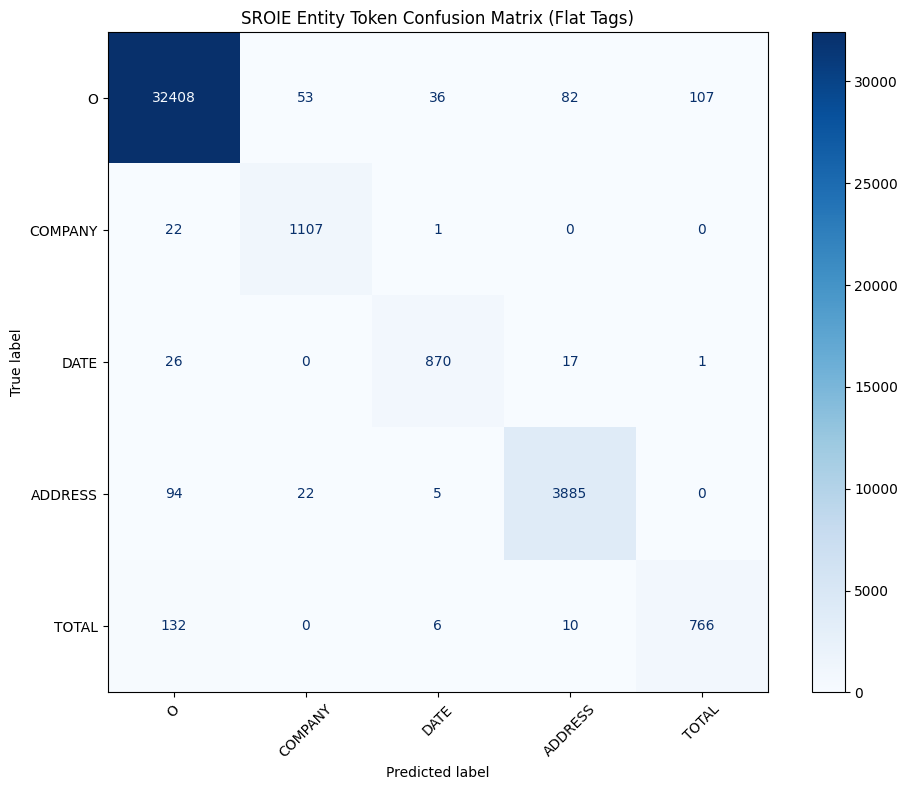

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==========================================
# 7. DETAILED EVALUATION & CONFUSION MATRIX
# ==========================================
print("Running final prediction on the test dataset...")
results = trainer.predict(encoded_datasets["test"])

# Extract logits and true labels
predictions = np.argmax(results.predictions, axis=2)
labels = results.label_ids

# Flatten the arrays and strictly filter out the -100 padding tokens
# Converting directly to string labels for a cleaner printed report
true_predictions = [
    ID2LABEL[p] for prediction, label in zip(predictions, labels)
    for (p, l) in zip(prediction, label) if l != -100
]

true_labels = [
    ID2LABEL[l] for prediction, label in zip(predictions, labels)
    for (p, l) in zip(prediction, label) if l != -100
]

# 1. Print the Detailed Classification Report
print("\n--- Detailed Classification Report ---")
# digits=4 gives you much more precise metric readouts (e.g., 0.9542 instead of 0.95)
print(classification_report(true_labels, true_predictions, digits=4))

# 2. Generate and Plot the Confusion Matrix
# We extract the specific ordering of our LABELS list to keep the matrix organized
unique_labels = [label for label in LABELS if label in true_labels or label in true_predictions]

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(true_labels, true_predictions, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)

# Plotting aesthetics
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("SROIE Entity Token Confusion Matrix (Flat Tags)")
plt.tight_layout() # Ensures bottom labels don't get cut off in Colab
plt.show()


Running Visual Inference on: ./sroie-datasetv2/SROIE2019/test/img/X00016469670.jpg


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]


--- Cleaned Extracted Data ---
COMPANY: OJC MARKETING SDN BHD
DATE: 2 15 01
ADDRESS: NO 2 &4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR
TOTAL: 193.00 193.00


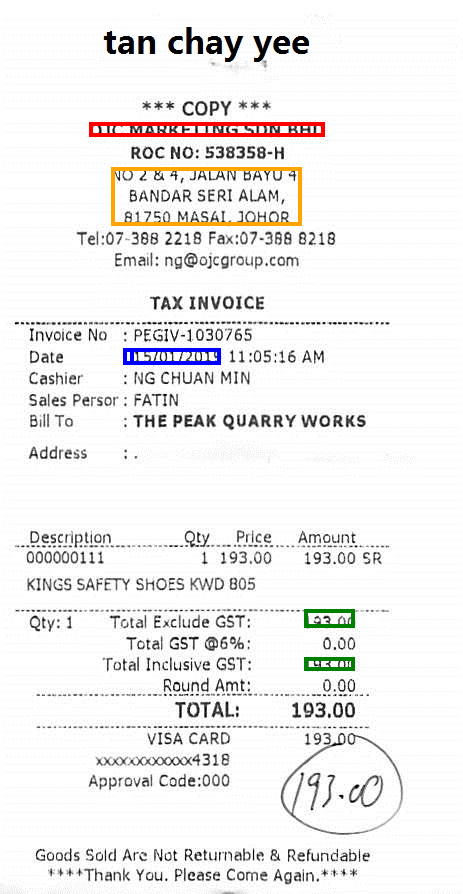

In [ ]:
# --- Run it ---
MODEL_DIR = "./layoutlmv3-sroie-model/checkpoint-316"
TEST_IMAGE = "./sroie-datasetv2/SROIE2019/test/img/X00016469670.jpg"
# In Colab, just call the function as the last line in your cell
test_visual_inference(TEST_IMAGE, MODEL_DIR)

Loading model into memory for batch testing...


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Running inference on 5 images...

--- Cleaned Extracted Data (X51005724622.jpg) ---
COMPANY: KEDAI PAPAN YEW CHUAN
DATE: 1 2 07 1
ADDRESS: LOT 276 JALAN BANTING 43800 DENGKIL, SELANGOR TAM DES DENGKIL SELANGOR
TOTAL: 91 91.
----------------------------------------
--- Cleaned Extracted Data (X51005663323.jpg) ---
COMPANY: KOH SENG HARDWARE
DATE: 04 2 2
ADDRESS: NO. 939, BATU LINA, JALAN IPOH, 51200 KUALA LUMPUR.
TOTAL: 848 0. 48.00 0 648.00 648.00 0. 48.00 © 48.00 418
----------------------------------------
--- Cleaned Extracted Data (X51006389898.jpg) ---
COMPANY: RESTORAN WAN SHF
DATE: 29
ADDRESS: No.2, Jalan Temengguns , Seksyen 9, Bandar Mahkota Cheras, 43200 Cheras, Selangor
TOTAL: 164 164. 40 164. 40
----------------------------------------
--- Cleaned Extracted Data (X51007339121.jpg) ---
COMPANY: SANYU STATIONERY SHOP
DATE: 12/09
ADDRESS: NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 SETIA ALAM
TOTAL: 0 7 0
----------------------------------------
--- Cleaned Extracted Data (X

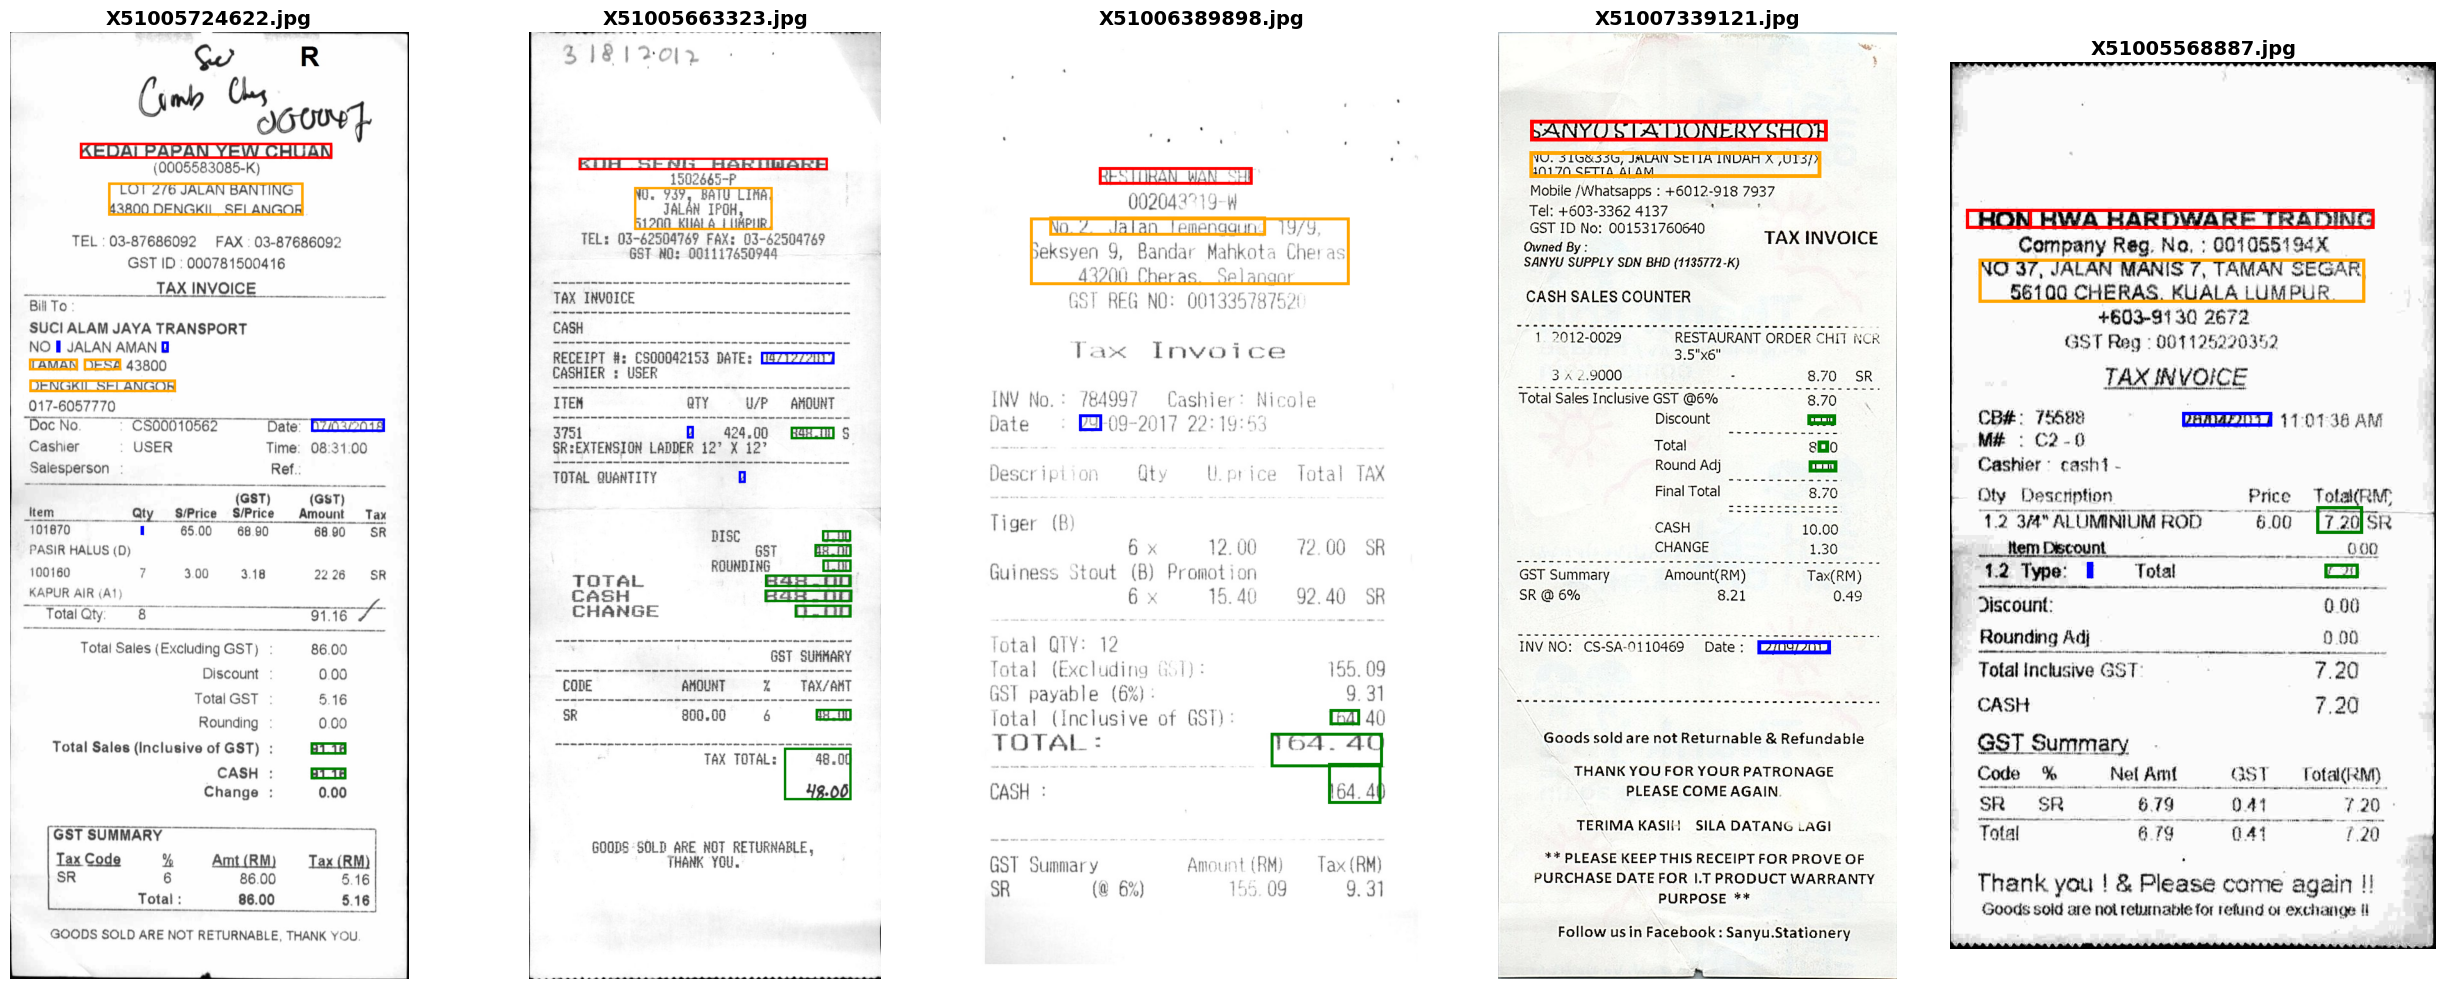

In [ ]:
import os
import random
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModelForTokenClassification

# ==========================================
# 8. OPTIMIZED BATCH INFERENCE (WITH TEXT OUTPUT)
# ==========================================
def run_batch_test(model_dir, num_images=5):
    print(f"Loading model into memory for batch testing...")
    inf_model = AutoModelForTokenClassification.from_pretrained(model_dir)
    inf_processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=True)

    test_img_dir = os.path.join(DATASET_DIR, "test", "img")
    all_images = [f for f in os.listdir(test_img_dir) if f.endswith(".jpg")]
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    fig, axes = plt.subplots(1, len(selected_images), figsize=(25, 10))
    if len(selected_images) == 1: axes = [axes]

    color_map = {"COMPANY": "red", "DATE": "blue", "ADDRESS": "orange", "TOTAL": "green"}

    print(f"Running inference on {len(selected_images)} images...\n")

    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(test_img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        encoding = inf_processor(image, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = inf_model(**encoding)

        predictions = outputs.logits.argmax(-1).squeeze().tolist()
        input_ids = encoding.input_ids.squeeze().tolist()
        boxes = encoding.bbox.squeeze().tolist()

        draw = ImageDraw.Draw(image)

        # Setup text tracking dictionary for this specific image
        results = {label: [] for label in LABELS if label != "O"}
        current_label = None
        current_box = None
        current_ids = []

        for pred, box, id_ in zip(predictions, boxes, input_ids):
            label = ID2LABEL[pred]

            if label == "O":
                if current_label:
                    # Draw Box
                    real_box = unnormalize_box(current_box, img_w, img_h)
                    draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=6)

                    # Extract Text
                    text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                    if text: results[current_label].append(text)

                current_label = None
                current_box = None
                current_ids = []
                continue

            if label != current_label:
                if current_label:
                    # Draw Box
                    real_box = unnormalize_box(current_box, img_w, img_h)
                    draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=6)

                    # Extract Text
                    text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                    if text: results[current_label].append(text)

                current_label = label
                current_box = box
                current_ids = [id_]
            else:
                current_box = merge_boxes(current_box, box)
                current_ids.append(id_)

        # Catch the final box/text at the end of the document
        if current_label:
            real_box = unnormalize_box(current_box, img_w, img_h)
            draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=6)
            text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
            if text: results[current_label].append(text)

        # Print the extracted data exactly as requested
        print(f"--- Cleaned Extracted Data ({img_name}) ---")
        for key, val_list in results.items():
            print(f"{key}: {' '.join(val_list)}")
        print("-" * 40) # Divider between images

        axes[i].imshow(image)
        axes[i].set_title(img_name, fontsize=14, fontweight="bold")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

run_batch_test("./layoutlmv3-sroie-model/checkpoint-316", num_images=5)